In [8]:
# ============================================================
# =============== CELL A — USER INPUTS ONLY ==================
# ============================================================

# ---- Parent session folder (contains multiple camera subfolders) ----
SESSION_FOLDER = r"D:\Kevin\05032026"   ###############################################################################################################################################################

# ---- NI-DAQ TTL folder (Neuropixels session) ----
NI_TTL_FOLDER = r"G:\Kevin\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL"  ################################################################################

# ---- Regex pattern for camera filenames ----
# Example: frame_030293_cnt_1575696.raw
FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw"   ###################################################################################################################################################

# ---- TTL pin for camera ----
TTL_PIN = 0   ################################################################################################################################################################################################

# ---- TTL block detection parameters ----
EXPECTED_RATE_HZ = 60    ####################################################################################################################################################################################
MISSING_TTL_THRESHOLD = 60  #################################################################################################################################################################################
MIN_BLOCK_LENGTH = 1000  ####################################################################################################################################################################################

print("User inputs loaded successfully.")
print(f"SESSION_FOLDER: {SESSION_FOLDER}")
print(f"NI_TTL_FOLDER: {NI_TTL_FOLDER}")
print(f"TTL_PIN: {TTL_PIN}")

User inputs loaded successfully.
SESSION_FOLDER: D:\Kevin\05032026
NI_TTL_FOLDER: G:\Kevin\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL
TTL_PIN: 0



===== TTL BLOCK DETECTOR =====
Loaded NI-DAQ data: 665277 samples
Detected 164217 rising edges on pin 0

Detected 5 TTL blocks (before filtering)
Skipping block 0 (too short: 1 TTLs)

Block 1:
  TTLs: 11631
  Start time: 676.130s
  End time:   870.081s
  Duration:   193.951s

Block 2:
  TTLs: 66686
  Start time: 931.433s
  End time:   2043.521s
  Duration:   1112.088s

Block 3:
  TTLs: 18732
  Start time: 2231.234s
  End time:   2543.607s
  Duration:   312.373s

Block 4:
  TTLs: 67167
  Start time: 2606.300s
  End time:   3726.411s
  Duration:   1120.110s


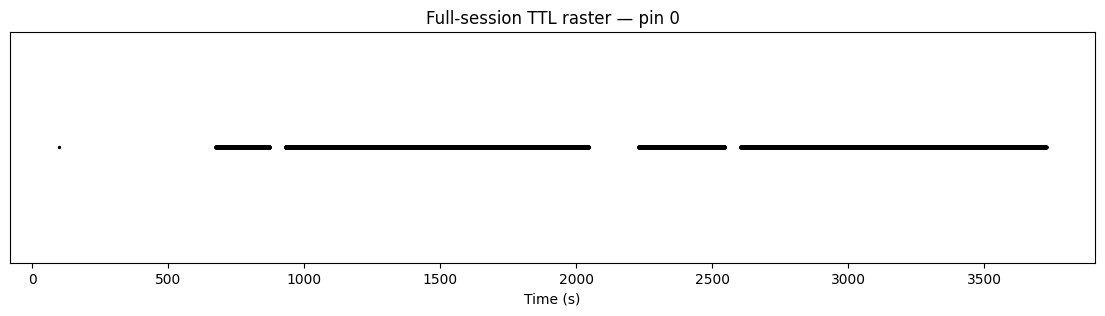

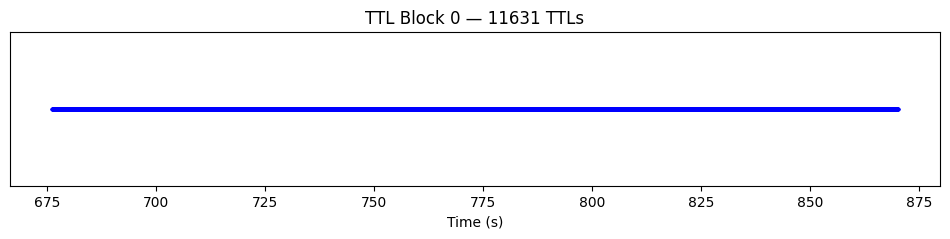

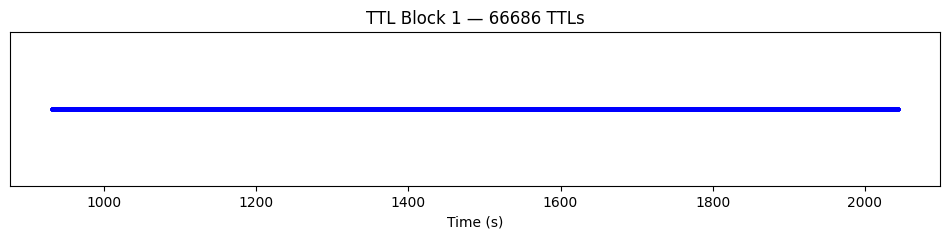

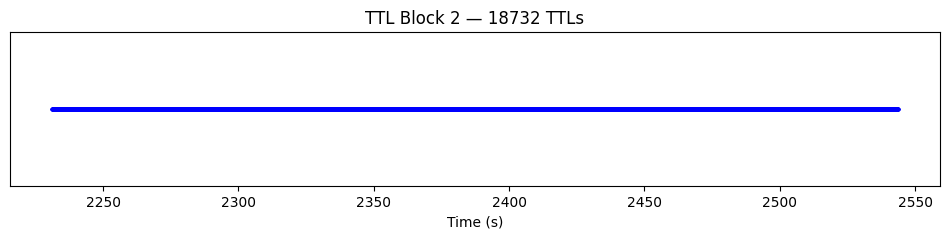

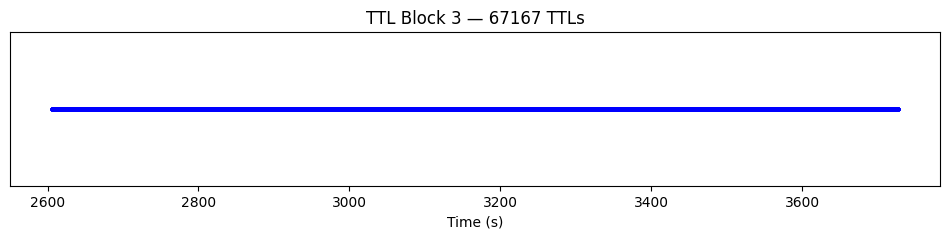


Review block_info and ttl_blocks above. If correct, proceed to Cell B.


In [9]:
# ============================================================
# CELL B— TTL BLOCK DETECTOR (NO SAVING)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

print("\n===== TTL BLOCK DETECTOR =====")

# ------------------------------------------------------------
# 1. Load NI-DAQ TTL data
# ------------------------------------------------------------
timestamps_ni = np.load(os.path.join(NI_TTL_FOLDER, "timestamps.npy"))
full_words_ni = np.load(os.path.join(NI_TTL_FOLDER, "full_words.npy"))

print(f"Loaded NI-DAQ data: {len(full_words_ni)} samples")

# ------------------------------------------------------------
# 2. Extract rising edges for camera TTL pin
# ------------------------------------------------------------
mask = 1 << TTL_PIN
bit_on = (full_words_ni & mask) > 0

bit_on_prev = np.roll(bit_on, 1)
bit_on_prev[0] = False

rising_idx = (~bit_on_prev) & (bit_on)
rising_times = timestamps_ni[rising_idx]

print(f"Detected {len(rising_times)} rising edges on pin {TTL_PIN}")

# ------------------------------------------------------------
# 3. Detect TTL blocks
# ------------------------------------------------------------
ipi = np.diff(rising_times)
expected_ipi = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD

gap_mask = ipi > gap_threshold
gap_indices = np.where(gap_mask)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

print(f"\nDetected {len(block_starts)} TTL blocks (before filtering)")

# ------------------------------------------------------------
# 4. Build block list
# ------------------------------------------------------------
ttl_blocks = []
block_info = []

for b, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1

    if block_len < MIN_BLOCK_LENGTH:
        print(f"Skipping block {b} (too short: {block_len} TTLs)")
        continue

    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)

    info = {
        "block_index": b,
        "ttl_start_index": int(start),
        "ttl_end_index": int(end),
        "n_ttls": int(block_len),
        "start_time_sec": float(block_times[0]),
        "end_time_sec": float(block_times[-1]),
        "duration_sec": float(block_times[-1] - block_times[0]),
        "gap_threshold_sec": float(gap_threshold)
    }

    block_info.append(info)

    print(f"\nBlock {b}:")
    print(f"  TTLs: {block_len}")
    print(f"  Start time: {block_times[0]:.3f}s")
    print(f"  End time:   {block_times[-1]:.3f}s")
    print(f"  Duration:   {block_times[-1] - block_times[0]:.3f}s")

# ------------------------------------------------------------
# 5. Visualize full session
# ------------------------------------------------------------
plt.figure(figsize=(14, 3))
plt.scatter(rising_times, np.zeros_like(rising_times), s=2, c='k')
plt.title(f"Full-session TTL raster — pin {TTL_PIN}")
plt.xlabel("Time (s)")
plt.yticks([])
plt.show()

# ------------------------------------------------------------
# 6. Visualize each block
# ------------------------------------------------------------
for b, block_times in enumerate(ttl_blocks):
    plt.figure(figsize=(12, 2))
    plt.scatter(block_times, np.zeros_like(block_times), s=3, c='blue')
    plt.title(f"TTL Block {b} — {len(block_times)} TTLs")
    plt.xlabel("Time (s)")
    plt.yticks([])
    plt.show()

print("\nReview block_info and ttl_blocks above. If correct, proceed to Cell B.")

In [19]:
# ============================================================
# CELL C - SELECT BLOCK + CAMERA FOLDER FOR ALIGNMENT
# ============================================================
# NOTE THAT 
# Choose which TTL block to use
block_index = 3   # <-- set manually for now ##################################################################################################################################################

# Choose which camera folder to align
CAM_FOLDER = r"D:\Kevin\05032026\05032026-9\cam2"   # <-- set manually ###########################################################################################################################

# Extract TTLs for this block
ttl_times_block = ttl_blocks[block_index]

print(f"Selected TTL block {block_index} with {len(ttl_times_block)} TTLs")
print(f"Selected camera folder: {CAM_FOLDER}")

Selected TTL block 3 with 67167 TTLs
Selected camera folder: D:\Kevin\05032026\05032026-9\cam2


In [20]:
# ============================================================
# ========== CELL D — BLOCK-AWARE FRAME ALIGNMENT ============
# ============================================================

import os
import re
import numpy as np

print("\n===== BLOCK-AWARE TTL ↔ Frame Alignment =====")

# ------------------------------------------------------------
# REQUIRED INPUTS (must already exist from previous cells)
# ------------------------------------------------------------
# CAM_FOLDER        : path to camera folder (string)
# FILENAME_PATTERN  : regex pattern for frame filenames (string)
# ttl_blocks        : list of TTL blocks from Cell A-BLOCK
# block_index       : integer index of the TTL block to use

# Example:
# block_index = 0
# ttl_times_block = ttl_blocks[block_index]

ttl_times_block = ttl_blocks[block_index]
TTL_COUNT = len(ttl_times_block)

print(f"Using TTL block {block_index} with {TTL_COUNT} TTL pulses")
print(f"Camera folder: {CAM_FOLDER}")

# ------------------------------------------------------------
# 1. Compile filename regex
# ------------------------------------------------------------
PATTERN = re.compile(FILENAME_PATTERN)

# ------------------------------------------------------------
# 2. Load camera frame filenames
# ------------------------------------------------------------
entries = []

for fname in os.listdir(CAM_FOLDER):
    m = PATTERN.match(fname)
    if m:
        frame_idx = int(m.group(1))
        counter   = int(m.group(2))
        entries.append((frame_idx, counter, fname))

if not entries:
    raise RuntimeError(f"No valid frame files found in {CAM_FOLDER}")

# Sort by chunk counter (camera truth)
entries.sort(key=lambda x: x[1])

frame_indices = np.array([e[0] for e in entries])
counters      = np.array([e[1] for e in entries])
filenames     = [e[2] for e in entries]

print(f"Loaded {len(entries)} frames from camera folder")

# ------------------------------------------------------------
# 3. Frame integrity check
# ------------------------------------------------------------
print("\n===== FRAME INTEGRITY CHECK =====")

missing_frame_idx_total = 0
missing_counter_total   = 0
problems = []

last_frame = None
last_counter = None

for frame_idx, counter, fname in entries:
    if last_frame is not None:

        # Frame index continuity
        expected_frame = last_frame + 1
        if frame_idx != expected_frame:
            gap = frame_idx - expected_frame
            missing_frame_idx_total += gap
            problems.append(
                f"FRAME INDEX GAP: {last_frame} → {frame_idx} (missing {gap})"
            )

        # Chunk counter continuity
        expected_counter = last_counter + 1
        if counter != expected_counter:
            gap = counter - expected_counter
            missing_counter_total += gap
            problems.append(
                f"CHUNK COUNTER GAP: {last_counter} → {counter} "
                f"(missing {gap}) at frame {frame_idx} ({fname})"
            )

    last_frame = frame_idx
    last_counter = counter

print(f"Total saved frames: {len(entries)}")
print(f"Missing by frame index: {missing_frame_idx_total}")
print(f"Missing by chunk counter: {missing_counter_total}")

if problems:
    print("\n⚠️  PROBLEMS DETECTED:")
    for p in problems:
        print(" -", p)
else:
    print("\n✅ No discrepancies detected.")

# ------------------------------------------------------------
# 4. TTL ↔ Frame alignment (BLOCK-AWARE)
# ------------------------------------------------------------
print("\n===== BUILDING TTL-ALIGNED TIMELINE (BLOCK MODE) =====")

aligned_frames = [None] * TTL_COUNT

# Map chunk counter → filename
counter_to_file = {c: f for (_, c, f) in entries}

# First counter in this camera folder
first_counter = counters[0]

for ttl_idx in range(TTL_COUNT):
    counter_value = first_counter + ttl_idx
    aligned_frames[ttl_idx] = counter_to_file.get(counter_value, None)

missing = sum(f is None for f in aligned_frames)

# ------------------------------------------------------------
# 5. Save output
# ------------------------------------------------------------
out_path = os.path.join(CAM_FOLDER, f"aligned_frames_block{block_index}.npy")
np.save(out_path, aligned_frames)

print(f"Saved aligned_frames_block{block_index}.npy → {out_path}")
print(f"Missing frames inserted: {missing}")

print("\n===== BLOCK ALIGNMENT COMPLETE =====\n")


===== BLOCK-AWARE TTL ↔ Frame Alignment =====
Using TTL block 3 with 67167 TTL pulses
Camera folder: D:\Kevin\05032026\05032026-9\cam2
Loaded 59140 frames from camera folder

===== FRAME INTEGRITY CHECK =====
Total saved frames: 59140
Missing by frame index: 0
Missing by chunk counter: 8026

⚠️  PROBLEMS DETECTED:
 - CHUNK COUNTER GAP: 108945 → 109439 (missing 493) at frame 9065 (frame_009065_cnt_109439.raw)
 - CHUNK COUNTER GAP: 112079 → 112525 (missing 445) at frame 11706 (frame_011706_cnt_112525.raw)
 - CHUNK COUNTER GAP: 115627 → 116090 (missing 462) at frame 14809 (frame_014809_cnt_116090.raw)
 - CHUNK COUNTER GAP: 118996 → 119474 (missing 477) at frame 17716 (frame_017716_cnt_119474.raw)
 - CHUNK COUNTER GAP: 122505 → 122977 (missing 471) at frame 20748 (frame_020748_cnt_122977.raw)
 - CHUNK COUNTER GAP: 126004 → 126471 (missing 466) at frame 23776 (frame_023776_cnt_126471.raw)
 - CHUNK COUNTER GAP: 129431 → 129905 (missing 473) at frame 26737 (frame_026737_cnt_129905.raw)
 - CH


===== Block-Aware Timeline Visualization =====
Full-session TTL pulses: 164217
Block 3 TTL pulses: 67167
Loaded aligned_frames_block3.npy successfully.

===== DURATIONS =====
NI-DAQ duration:     3729.39 s
TTL block duration:  1120.11 s
Frame timeline:      1120.11 s


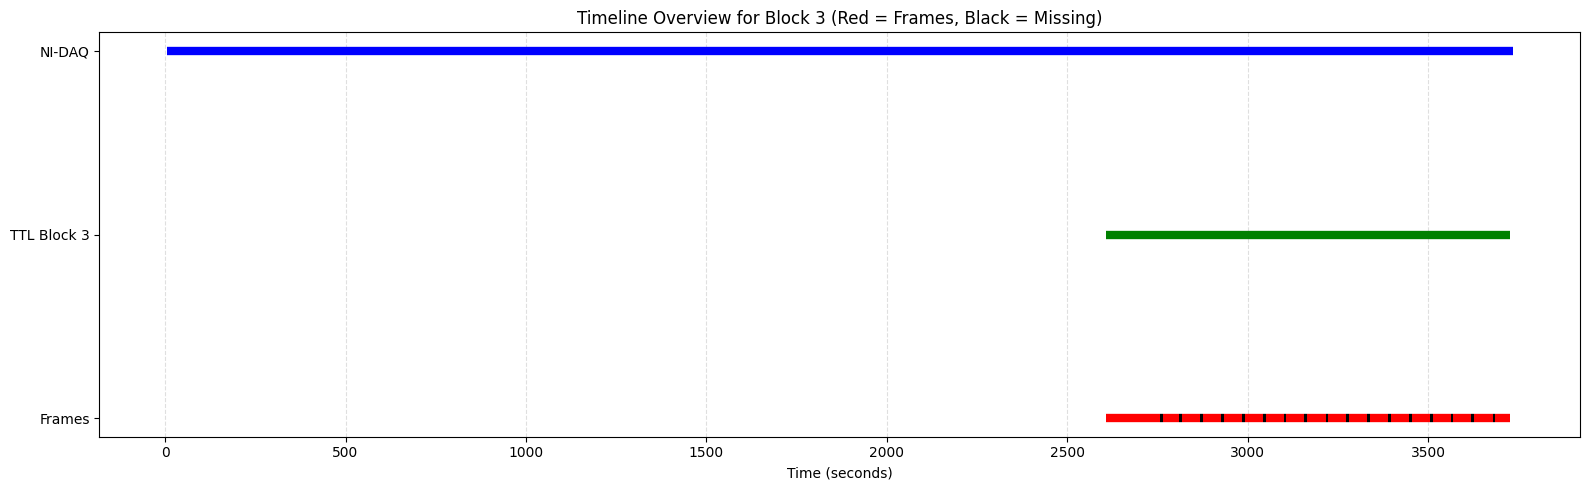


===== BLOCK TIMELINE VISUALIZATION COMPLETE =====



In [21]:
# ============================================================
# ========== CELL E — BLOCK-AWARE TIMELINE VISUALIZATION =====
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

print("\n===== Block-Aware Timeline Visualization =====")

# ------------------------------------------------------------
# REQUIRED INPUTS (must exist from previous cells)
# ------------------------------------------------------------
# NI_TTL_FOLDER
# TTL_PIN
# ttl_times_block
# block_index
# CAM_FOLDER

# ------------------------------------------------------------
# 1. Load NI-DAQ full-session TTL data (for context)
# ------------------------------------------------------------
timestamps_ni = np.load(os.path.join(NI_TTL_FOLDER, "timestamps.npy"))
full_words_ni = np.load(os.path.join(NI_TTL_FOLDER, "full_words.npy"))

bit_mask = 1 << TTL_PIN
ttl_signal = (full_words_ni & bit_mask) > 0
ttl_diff = np.diff(ttl_signal.astype(int))
rising_edges = np.where(ttl_diff == 1)[0] + 1

ttl_times_full = timestamps_ni[rising_edges]

print(f"Full-session TTL pulses: {len(ttl_times_full)}")
print(f"Block {block_index} TTL pulses: {len(ttl_times_block)}")

# ------------------------------------------------------------
# 2. Load aligned frames for this block
# ------------------------------------------------------------
aligned_path = os.path.join(CAM_FOLDER, f"aligned_frames_block{block_index}.npy")
aligned_frames = np.load(aligned_path, allow_pickle=True)

assert len(aligned_frames) == len(ttl_times_block), \
    f"Mismatch: block TTLs={len(ttl_times_block)} but aligned_frames={len(aligned_frames)}"

print(f"Loaded aligned_frames_block{block_index}.npy successfully.")

# ------------------------------------------------------------
# 3. Compute durations
# ------------------------------------------------------------
ni_start = timestamps_ni[0]
ni_end   = timestamps_ni[-1]
ni_duration = ni_end - ni_start

block_start = ttl_times_block[0]
block_end   = ttl_times_block[-1]
block_duration = block_end - block_start

print("\n===== DURATIONS =====")
print(f"NI-DAQ duration:     {ni_duration:.2f} s")
print(f"TTL block duration:  {block_duration:.2f} s")
print(f"Frame timeline:      {block_duration:.2f} s")

# ------------------------------------------------------------
# 4. Visualization
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 5))

# Row positions
y_ni = 3
y_ttl = 2
y_frames = 1

# --- NI-DAQ full recording ---
ax.hlines(y_ni, ni_start, ni_end, color='blue', linewidth=6, label="NI-DAQ Recording")

# --- TTL block window ---
ax.hlines(y_ttl, block_start, block_end, color='green', linewidth=6, label=f"TTL Block {block_index}")

# --- Frame timeline (red = present, black = missing) ---
TTL_COUNT = len(ttl_times_block)

for i, f in enumerate(aligned_frames):
    t0 = ttl_times_block[i]
    if i < TTL_COUNT - 1:
        t1 = ttl_times_block[i+1]
    else:
        # last interval same width as previous
        t1 = t0 + (ttl_times_block[-1] - ttl_times_block[-2])

    color = 'red' if f is not None else 'black'
    ax.hlines(y_frames, t0, t1, color=color, linewidth=6)

ax.set_yticks([y_ni, y_ttl, y_frames])
ax.set_yticklabels(["NI-DAQ", f"TTL Block {block_index}", "Frames"])

ax.set_xlabel("Time (seconds)")
ax.set_title(f"Timeline Overview for Block {block_index} (Red = Frames, Black = Missing)")
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n===== BLOCK TIMELINE VISUALIZATION COMPLETE =====\n")

In [3]:
# ============================================================
# ========== CELL F — BLOCK-AWARE DLC ↔ TTL ALIGNMENT ========
# ============================================================

import os
import numpy as np
import pandas as pd

print("\n===== BLOCK-AWARE DLC ↔ TTL Alignment =====")

# ------------------------------------------------------------
# REQUIRED INPUTS (must already exist)
# ------------------------------------------------------------
# CAM_FOLDER
# block_index
# ttl_times_block
# DLC_OUTPUT_PATH

# ------------------------------------------------------------
# 1. Load aligned_frames for this block
# ------------------------------------------------------------
aligned_path = os.path.join(CAM_FOLDER, f"aligned_frames_block{block_index}.npy")
aligned_frames = np.load(aligned_path, allow_pickle=True)

TTL_COUNT = len(aligned_frames)
print(f"Loaded aligned_frames_block{block_index}.npy with {TTL_COUNT} TTL entries.")

# ------------------------------------------------------------
# 2. Load DLC output
# ------------------------------------------------------------
if DLC_OUTPUT_PATH.endswith(".csv"):
    df_dlc = pd.read_csv(DLC_OUTPUT_PATH)
elif DLC_OUTPUT_PATH.endswith(".h5") or DLC_OUTPUT_PATH.endswith(".hdf5"):
    df_dlc = pd.read_hdf(DLC_OUTPUT_PATH)
else:
    raise ValueError("DLC output must be .csv or .h5")

DLC_FRAME_COUNT = len(df_dlc)
print(f"Loaded DLC output with {DLC_FRAME_COUNT} rows.")

# ------------------------------------------------------------
# 3. DLC row mapping
# ------------------------------------------------------------
# DLC row i corresponds to the i-th PRESENT frame in the video.
# Missing frames were removed during video encoding.

dlc_by_row = {i: df_dlc.iloc[i] for i in range(DLC_FRAME_COUNT)}

# ------------------------------------------------------------
# 4. Extract raw frame indices for PRESENT frames
# ------------------------------------------------------------
present_raw_indices = [
    int(f.split("_")[1])
    for f in aligned_frames
    if f is not None
]

# DLC rows correspond to the ORDER of present frames
raw_to_dlc_row = {
    raw_idx: i
    for i, raw_idx in enumerate(present_raw_indices)
    if i < DLC_FRAME_COUNT
}

# ------------------------------------------------------------
# 5. Build TTL-aligned DLC timeline
# ------------------------------------------------------------
dlc_aligned = []

for f in aligned_frames:
    if f is None:
        dlc_aligned.append(None)
    else:
        raw_idx = int(f.split("_")[1])
        dlc_row = raw_to_dlc_row.get(raw_idx, None)
        if dlc_row is None:
            dlc_aligned.append(None)
        else:
            dlc_aligned.append(dlc_by_row[dlc_row])

dlc_aligned = np.array(dlc_aligned, dtype=object)

print("Built block-aware dlc_aligned timeline.")
print(f"Length: {len(dlc_aligned)}")
print(f"Missing DLC entries: {sum(x is None for x in dlc_aligned)}")

# ------------------------------------------------------------
# 6. Save output
# ------------------------------------------------------------
output_path = os.path.join(CAM_FOLDER, f"dlc_aligned_block{block_index}.npy")
np.save(output_path, dlc_aligned)

print(f"\nSaved dlc_aligned_block{block_index}.npy to:\n{output_path}")
print("\n===== BLOCK-AWARE DLC ALIGNMENT COMPLETE =====\n")


===== DLC ↔ TTL Alignment Module =====


NameError: name 'CAM_FOLDER' is not defined

In [4]:
# ============================================================
# ========== CELL G — DLC TRAJECTORY PLOTTING MODULE =========
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n===== DLC Trajectory Plotting Module =====")

# ------------------------------------------------------------
# 1. Load dlc_aligned.npy
# ------------------------------------------------------------
dlc_aligned_path = os.path.join(CAM_FOLDER, "dlc_aligned.npy")
dlc_aligned = np.load(dlc_aligned_path, allow_pickle=True)

print(f"Loaded dlc_aligned timeline with {len(dlc_aligned)} entries.")

# ------------------------------------------------------------
# 2. Load DLC dataframe to inspect column structure
# ------------------------------------------------------------
df_dlc = pd.read_hdf(DLC_OUTPUT_PATH)

# Choose bodypart
bodypart = "paw"   ##############################################################################################################################################################

# Extract columns
cols = [c for c in df_dlc.columns if c[1] == bodypart]
x_col = [c for c in cols if c[2] == "x"][0]
y_col = [c for c in cols if c[2] == "y"][0]
lik_col = [c for c in cols if c[2] == "likelihood"][0]

# ------------------------------------------------------------
# 3. Build aligned trajectories
# ------------------------------------------------------------
x_aligned = []
y_aligned = []
lik_aligned = []

for row in dlc_aligned:
    if row is None:
        x_aligned.append(np.nan)
        y_aligned.append(np.nan)
        lik_aligned.append(np.nan)
    else:
        x_aligned.append(row[x_col])
        y_aligned.append(row[y_col])
        lik_aligned.append(row[lik_col])

x_aligned = np.array(x_aligned, dtype=float)
y_aligned = np.array(y_aligned, dtype=float)
lik_aligned = np.array(lik_aligned, dtype=float)

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(x_aligned, color='red', linewidth=1)
ax[0].set_ylabel("X (px)")
ax[0].set_title(f"{bodypart} — X trajectory (TTL-aligned)")

ax[1].plot(y_aligned, color='blue', linewidth=1)
ax[1].set_ylabel("Y (px)")
ax[1].set_xlabel("TTL index")
ax[1].set_title(f"{bodypart} — Y trajectory (TTL-aligned)")

plt.tight_layout()
plt.show()

print("\n===== MODULE COMPLETE =====\n")


===== DLC Trajectory Plotting Module =====


NameError: name 'CAM_FOLDER' is not defined

In [12]:
# ============================================================
# ========== CELL F — SANITY CHECK MODULE ====================
# ============================================================

import os
import numpy as np

print("\n===== Sanity Check Module =====")

aligned_frames = np.load(os.path.join(CAM_FOLDER, "aligned_frames.npy"), allow_pickle=True)
dlc_aligned    = np.load(os.path.join(CAM_FOLDER, "dlc_aligned.npy"), allow_pickle=True)

TTL_COUNT = len(aligned_frames)

print(f"TTL count: {TTL_COUNT}")
print(f"DLC-aligned length: {len(dlc_aligned)}")

# ------------------------------------------------------------
# 1. Check that every present frame has a DLC entry
# ------------------------------------------------------------
present_frames = sum(f is not None for f in aligned_frames)
present_dlc    = sum(x is not None for x in dlc_aligned)

print(f"Present frames: {present_frames}")
print(f"Present DLC entries: {present_dlc}")

if present_frames != present_dlc:
    print("⚠️ Mismatch detected: DLC entries do not match present frames.")
else:
    print("✅ DLC entries match present frames exactly.")

# ------------------------------------------------------------
# 2. Check for any DLC values outside expected range
# ------------------------------------------------------------
y_vals = np.array([
    row[y_col] if row is not None else np.nan
    for row in dlc_aligned
])

print(f"Max Y in DLC-aligned: {np.nanmax(y_vals)}")
print(f"Min Y in DLC-aligned: {np.nanmin(y_vals)}")

print("\n===== MODULE COMPLETE =====\n")


===== Sanity Check Module =====
TTL count: 134516
DLC-aligned length: 134516
Present frames: 120268
Present DLC entries: 120268
✅ DLC entries match present frames exactly.
Max Y in DLC-aligned: 214.2211456298828
Min Y in DLC-aligned: 128.0848388671875

===== MODULE COMPLETE =====



In [5]:
# ============================================================
# ========== CELL G — PEAK DETECTION MODULE ==================
# ============================================================

import os
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

print("\n===== Peak Detection Module =====")

# ------------------------------------------------------------
# 1. Load aligned DLC trajectories (from Cell E)
# ------------------------------------------------------------
dlc_aligned_path = os.path.join(CAM_FOLDER, "dlc_aligned.npy")
dlc_aligned = np.load(dlc_aligned_path, allow_pickle=True)

# Load aligned_frames (from Cell B)
aligned_frames_path = os.path.join(CAM_FOLDER, "aligned_frames.npy")
aligned_frames = np.load(aligned_frames_path, allow_pickle=True)

TTL_COUNT = len(aligned_frames)
assert len(dlc_aligned) == TTL_COUNT, "Mismatch: dlc_aligned and aligned_frames lengths differ."

# ------------------------------------------------------------
# 2. Load DLC dataframe to get column structure
# ------------------------------------------------------------
df_dlc = pd.read_hdf(DLC_OUTPUT_PATH)

bodypart = "paw"   # You can change this if needed ##################################################################################################################################################

cols = [c for c in df_dlc.columns if c[1] == bodypart]
x_col   = [c for c in cols if c[2] == "x"][0]
y_col   = [c for c in cols if c[2] == "y"][0]
lik_col = [c for c in cols if c[2] == "likelihood"][0]

# ------------------------------------------------------------
# 3. Build aligned trajectories
# ------------------------------------------------------------
x_aligned = []
y_aligned = []
lik_aligned = []

for row in dlc_aligned:
    if row is None:
        x_aligned.append(np.nan)
        y_aligned.append(np.nan)
        lik_aligned.append(np.nan)
    else:
        x_aligned.append(row[x_col])
        y_aligned.append(row[y_col])
        lik_aligned.append(row[lik_col])

x_aligned = np.array(x_aligned, dtype=float)
y_aligned = np.array(y_aligned, dtype=float)
lik_aligned = np.array(lik_aligned, dtype=float)

# ------------------------------------------------------------
# 4. Peak detection settings
# ------------------------------------------------------------
threshold = 190          # Y-value threshold for a peak   ############################################################################################################################################
min_peak_distance = 50   # Minimum TTL indices between peaks #########################################################################################################################################

print(f"Using threshold = {threshold}, min_peak_distance = {min_peak_distance}")

# ------------------------------------------------------------
# 5. Detect peaks
# ------------------------------------------------------------
peaks, props = find_peaks(
    y_aligned,
    height=threshold,
    distance=min_peak_distance
)

print(f"Detected {len(peaks)} peaks above threshold.")

# ------------------------------------------------------------
# 6. Build results list (TTL index, raw frame index, Y value)
# ------------------------------------------------------------
results = []

for ttl_idx in peaks:
    fname = aligned_frames[ttl_idx]
    if fname is None:
        raw_idx = None
    else:
        raw_idx = int(fname.split("_")[1])

    peak_y = y_aligned[ttl_idx]
    results.append((ttl_idx, raw_idx, peak_y))

# Print results
print("\n===== PEAK RESULTS =====")
for ttl_idx, raw_idx, peak_y in results:
    print(f"TTL {ttl_idx:6d} | Frame {raw_idx:6d} | Y = {peak_y:.2f}")

# ------------------------------------------------------------
# 7. Plot with peak annotations
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_aligned, color='blue', linewidth=1)
ax.scatter(peaks, y_aligned[peaks], color='red', s=25, label="Detected peaks")

# Annotate with raw frame numbers
for ttl_idx, raw_idx, peak_y in results:
    if raw_idx is not None:
        ax.text(ttl_idx, peak_y + 3, str(raw_idx), fontsize=8, color='black')

ax.set_title(f"{bodypart} — Peak Detection (threshold = {threshold})")
ax.set_xlabel("TTL index")
ax.set_ylabel("Y coordinate (px)")
ax.legend()

plt.tight_layout()
plt.show()

print("\n===== MODULE COMPLETE =====\n")


===== Peak Detection Module =====


NameError: name 'CAM_FOLDER' is not defined